# Accelerometer Data Classification Pipeline

This notebook presents an end-to-end pipeline for binary classification of human emotional states ('Calm' vs. 'Agitated') based on simulated MPU6050 accelerometer data. The methodology aligns with common practices in Human Activity Recognition (HAR) and Machine Learning.

**Pipeline Overview:**

1.  **Data Generation:**
    *   Simulated MPU6050-like 3-axis accelerometer (X, Y, Z) data is generated for two distinct classes: 'Calm' (class 0) and 'Agitated' (class 1). The 'Agitated' state is designed with significantly higher variability, amplitude, and occasional spikes to create a challenging classification scenario.

2.  **Preprocessing:**
    *   **Moving Average Filter:** A low-pass moving average filter is applied to the raw continuous data to smooth out high-frequency noise, as is common in sensor data processing.
    *   **Sliding Window Segmentation:** The filtered continuous data is then segmented into overlapping windows (e.g., 128 samples with 50% overlap). This technique transforms the time-series data into discrete instances suitable for feature extraction, with each window assigned the majority label present within it.

3.  **Feature Extraction:**
    *   For each segmented window, a comprehensive set of features is extracted across the temporal and frequency domains for each axis (X, Y, Z). These include:
        *   **Temporal Features:** Standard deviation, skewness, and kurtosis to capture data distribution characteristics.
        *   **Frequency Features:** Mean and standard deviation of Power Spectral Density (PSD) using Welch's method, and the first 32 amplitude coefficients from the Fast Fourier Transform (FFT), to represent the signal's frequency content.
    *   **Inter-axial Features:** Pearson correlation coefficients between the X, Y, and Z axes are computed to capture relationships between sensor dimensions.

4.  **Feature Selection (Dimensionality Reduction):**
    *   **Principal Component Analysis (PCA):** PCA is applied to the extracted features to reduce dimensionality while preserving a user-defined cumulative explained variance (e.g., 95%). This step mitigates the curse of dimensionality, reduces model complexity, and helps prevent overfitting.

5.  **Model Training and Evaluation:**
    *   **Train-Test Split:** The PCA-transformed feature set is split into training and testing subsets, ensuring stratification to maintain class proportions.
    *   **RandomForestClassifier:** A RandomForestClassifier is chosen for its robustness and ability to handle high-dimensional data. Hyperparameter tuning is performed using `GridSearchCV` with cross-validation to find the optimal combination of `n_estimators`, `max_depth`, and `min_samples_split`.
    *   **Evaluation Metrics:** Model performance is assessed using accuracy score, a detailed classification report (precision, recall, f1-score), and a confusion matrix to visualize true positives, true negatives, false positives, and false negatives.

6.  **Real-time Inference (Deployment Simulation):**
    *   The trained RandomForest model and the fitted PCA transformer are serialized (`joblib.dump`) for potential deployment.
    *   A `predict_realtime` function is implemented, demonstrating how a new, single window of raw accelerometer data would pass through the same preprocessing, feature extraction, and PCA steps before a probability prediction for 'Agitated' (stress) is made by the loaded model. This function adheres to a defined ML data contract for input and output.

This pipeline provides a robust framework for classifying emotional states from accelerometer data, incorporating standard signal processing and machine learning techniques, and demonstrating readiness for real-world application with its real-time inference capability.


### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from scipy.signal import welch # For Power Spectral Density
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA # For Feature Selection
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42) # Set a random seed for reproducibility

In [2]:
EMOTION_LABELS = {0: 'Calm', 1: 'Agitated'}

### 2. Data Generation Function

This function simulates MPU6050-like data for two classes ('calm' and 'agitated') with high noise and overlap to make the classification task challenging.

In [3]:
def generate_simulated_continuous_data(duration_per_emotion=60, sampling_rate=5):
    """
    Generates continuous, simulated accelerometer data for Neutral and Agitated emotions.
    Each emotion type has distinct but overlapping characteristics.

    Args:
        duration_per_emotion (int): Duration in seconds for each emotion's continuous data.
        sampling_rate (int): Number of samples per second.

    Returns:
        tuple: A tuple containing:
            - np.ndarray: The concatenated continuous X, Y, Z data.
            - np.ndarray: The concatenated labels (0=Neutral, 1=Agitated).
    """
    total_samples_per_emotion = duration_per_emotion * sampling_rate

    all_data = []
    all_labels = []

    # Calm: Low variability, specific means as per user's provided data
    mean_x_calm = -0.12
    mean_y_calm = -0.002
    mean_z_calm = 1.05
    std_calm = 0.02      # Very low standard deviation for calm

    x_calm = np.random.normal(mean_x_calm, std_calm, total_samples_per_emotion)
    y_calm = np.random.normal(mean_y_calm, std_calm, total_samples_per_emotion)
    z_calm = np.random.normal(mean_z_calm, std_calm, total_samples_per_emotion)
    all_data.append(np.column_stack([x_calm, y_calm, z_calm]))
    all_labels.append(np.full(total_samples_per_emotion, 0)) # 0 for Calm

    # Agitated: High variability, higher base mean for Z and wider fluctuations
    mean_x_agitated = 0.0   # Center around zero for x/y
    mean_y_agitated = 0.0
    mean_z_agitated = 1.0   # Closer to calm's z, but with large variance

    # Increased values to make agitated accelerations 'much larger'
    std_agitated_base = 1.0
    std_agitated_noise = 2.0

    x_agitated = np.random.normal(mean_x_agitated, std_agitated_base, total_samples_per_emotion) + \
                 np.sin(np.linspace(0, 10 * np.pi, total_samples_per_emotion)) * 2.0 + \
                 np.random.normal(0, std_agitated_noise, total_samples_per_emotion) # Increased amplitude

    y_agitated = np.random.normal(mean_y_agitated, std_agitated_base, total_samples_per_emotion) + \
                 np.cos(np.linspace(0, 10 * np.pi, total_samples_per_emotion)) * 2.0 + \
                 np.random.normal(0, std_agitated_noise, total_samples_per_emotion) # Increased amplitude

    z_agitated = np.random.normal(mean_z_agitated, std_agitated_base, total_samples_per_emotion) + \
                 np.random.uniform(-1.0, 1.0, total_samples_per_emotion) + \
                 np.sin(np.linspace(0, 8 * np.pi, total_samples_per_emotion)) * 3.0 + \
                 np.random.normal(0, std_agitated_noise, total_samples_per_emotion) # Increased amplitude

    # Introduce occasional larger spikes for agitated-like motion, more frequent than before
    num_spikes_agitated = total_samples_per_emotion // 50
    spike_indices_agitated = np.random.choice(total_samples_per_emotion, num_spikes_agitated, replace=False)
    spike_magnitude = np.random.uniform(50.0, 150.0, num_spikes_agitated) # Significantly increased magnitude

    # Directly add spike magnitude, with random sign, to ensure values reach hundreds
    x_agitated[spike_indices_agitated] += spike_magnitude * np.random.choice([-1, 1], size=num_spikes_agitated)
    y_agitated[spike_indices_agitated] += spike_magnitude * np.random.choice([-1, 1], size=num_spikes_agitated)
    z_agitated[spike_indices_agitated] += spike_magnitude * np.random.choice([-1, 1], size=num_spikes_agitated)

    all_data.append(np.column_stack([x_agitated, y_agitated, z_agitated]))
    all_labels.append(np.full(total_samples_per_emotion, 1)) # 1 for Agitated

    return np.vstack(all_data), np.concatenate(all_labels)

### 3. Feature Extraction Function

This function extracts statistical features (standard deviation, skewness, kurtosis) and the dominant frequency (using FFT) for each axis (X, Y, Z) from a given window of accelerometer data.

In [4]:
def extract_features(window_data, sampling_rate):
    features = []
    # Number of FFT coefficients to extract
    num_fft_coeffs = 32

    # Iterate over X, Y, Z axes
    for i in range(3):
        axis_data = window_data[:, i]

        # Temporal Domain Features (Skewness, Kurtosis, Standard Deviation)
        features.append(np.std(axis_data))
        features.append(skew(axis_data))
        features.append(kurtosis(axis_data))

        # Frequency Domain Features: Mean and Standard Deviation of Power Spectral Density (PSD)
        # Using Welch's method to estimate PSD
        freqs, psd = welch(axis_data, fs=sampling_rate, nperseg=len(axis_data), scaling='density')
        features.append(np.mean(psd))
        features.append(np.std(psd))

        # Temporal-Frequency Domain: First N amplitude coefficients from Fast Fourier Transform (FFT)
        N = len(axis_data)
        yf = fft(axis_data)[:N // 2]  # Take only positive frequencies
        # Get the magnitude of the FFT, normalized
        amplitudes = 2.0 / N * np.abs(yf)
        # Pad or truncate to ensure exactly num_fft_coeffs
        if len(amplitudes) >= num_fft_coeffs:
            features.extend(amplitudes[:num_fft_coeffs])
        else:
            # Pad with zeros if not enough coefficients
            features.extend(np.pad(amplitudes, (0, num_fft_coeffs - len(amplitudes)), 'constant'))

    # Correlations between axes (P_xy, P_xz, P_yz)
    # Ensure window_data has enough samples for correlation calculation
    if window_data.shape[0] > 1:
        corr_xy = np.corrcoef(window_data[:, 0], window_data[:, 1])[0, 1]
        corr_xz = np.corrcoef(window_data[:, 0], window_data[:, 2])[0, 1]
        corr_yz = np.corrcoef(window_data[:, 1], window_data[:, 2])[0, 1]
        features.extend([corr_xy, corr_xz, corr_yz])
    else:
        features.extend([0.0, 0.0, 0.0]) # Append zeros if correlation cannot be computed

    return np.array(features)

### 4. Preprocessing Functions

These functions implement the Moving Average Filter and Sliding Window as described in the research paper to prepare the continuous data for feature extraction.

In [5]:
def moving_average_filter(data, window_size):
    """
    Applies a moving average filter to the accelerometer data.

    Args:
        data (np.ndarray): Input accelerometer data (N, 3).
        window_size (int): Size of the moving average window.

    Returns:
        np.ndarray: Filtered data.
    """
    # Calculate the length of the output after 'valid' convolution
    output_length = data.shape[0] - window_size + 1
    filtered_data = np.zeros((output_length, data.shape[1]), dtype=float)

    for i in range(data.shape[1]): # Iterate over X, Y, Z axes
        filtered_data[:, i] = np.convolve(data[:, i], np.ones(window_size)/window_size, mode='valid')

    return filtered_data

In [6]:
def sliding_window(data, labels, window_size, overlap):
    """
    Segments continuous data into overlapping windows.

    Args:
        data (np.ndarray): Continuous accelerometer data (N, 3).
        labels (np.ndarray): Corresponding continuous labels (N,).
        window_size (int): Number of samples in each window.
        overlap (int): Number of overlapping samples between consecutive windows.

    Returns:
        tuple: A tuple containing:
            - list: List of segmented data windows.
            - list: List of labels for each window (most frequent label in window).
    """
    step = window_size - overlap
    windows = []
    window_labels = []

    for i in range(0, len(data) - window_size + 1, step):
        window = data[i : i + window_size]
        window_label = labels[i : i + window_size]

        # Only add windows if they contain enough data for feature extraction
        if len(window) == window_size:
            windows.append(window)
            # Assign the majority label to the window
            # If there's a tie, np.bincount takes the smallest label
            window_labels.append(np.bincount(window_label).argmax())

    return np.array(windows), np.array(window_labels)


### 5. Demonstration of Data Generation, Preprocessing, and Feature Distribution Plotting

This section demonstrates the use of the new data generation and preprocessing functions, and then visualizes the distributions of some features for the three emotion classes.

Generating continuous simulated data...
Continuous data shape: (12000, 3)
Continuous labels shape: (12000,)

2. Applying Moving Average Filter with window size 5...
Filtered data shape: (11996, 3)
Adjusted labels shape: (11996,)

3. Applying Sliding Window with size 128 and overlap 64...
Number of windows: 186
Shape of first window: (128, 3)
Number of window labels: 186
Class distribution in windows: [93 93]

4. Extracting features from windows...
Shape of features DataFrame: (186, 115)


,std_x,skew_x,kurt_x,mean_psd_x,std_psd_x,fft_amp_x_1,fft_amp_x_2,fft_amp_x_3,fft_amp_x_4,fft_amp_x_5,...,fft_amp_z_27,fft_amp_z_28,fft_amp_z_29,fft_amp_z_30,fft_amp_z_31,fft_amp_z_32,corr_xy,corr_xz,corr_yz,label
0,0.007666,-0.171367,-0.568655,0.000002,0.000003,0.243158,0.003009,0.004543,0.002066,0.001781,...,0.000369,0.000352,0.000534,0.000292,0.000294,0.000146,-0.060813,-0.046718,0.030441,0
1,0.006990,0.156404,-0.352881,0.000002,0.000003,0.238652,0.002249,0.002521,0.002691,0.001639,...,0.000171,0.000233,0.000433,0.000612,0.000219,0.000601,0.132440,-0.209860,-0.003592,0
2,0.007971,1.102879,1.552806,0.000004,0.000008,0.236766,0.002080,0.001445,0.004843,0.003278,...,0.000151,0.000453,0.000375,0.000736,0.000331,0.000187,0.041023,-0.278769,0.194513,0
3,0.008325,0.420180,1.980729,0.000003,0.000005,0.236667,0.004426,0.000380,0.002602,0.004932,...,0.000352,0.000127,0.000487,0.000768,0.000359,0.000245,0.017607,0.032520,0.194062,0
4,0.008484,-0.413998,0.408859,0.000002,0.000005,0.238647,0.002771,0.005098,0.004548,0.002737,...,0.000199,0.000244,0.000310,0.000895,0.000631,0.000150,0.211940,0.036708,-0.041986,0



5. Plotting selected feature distributions...


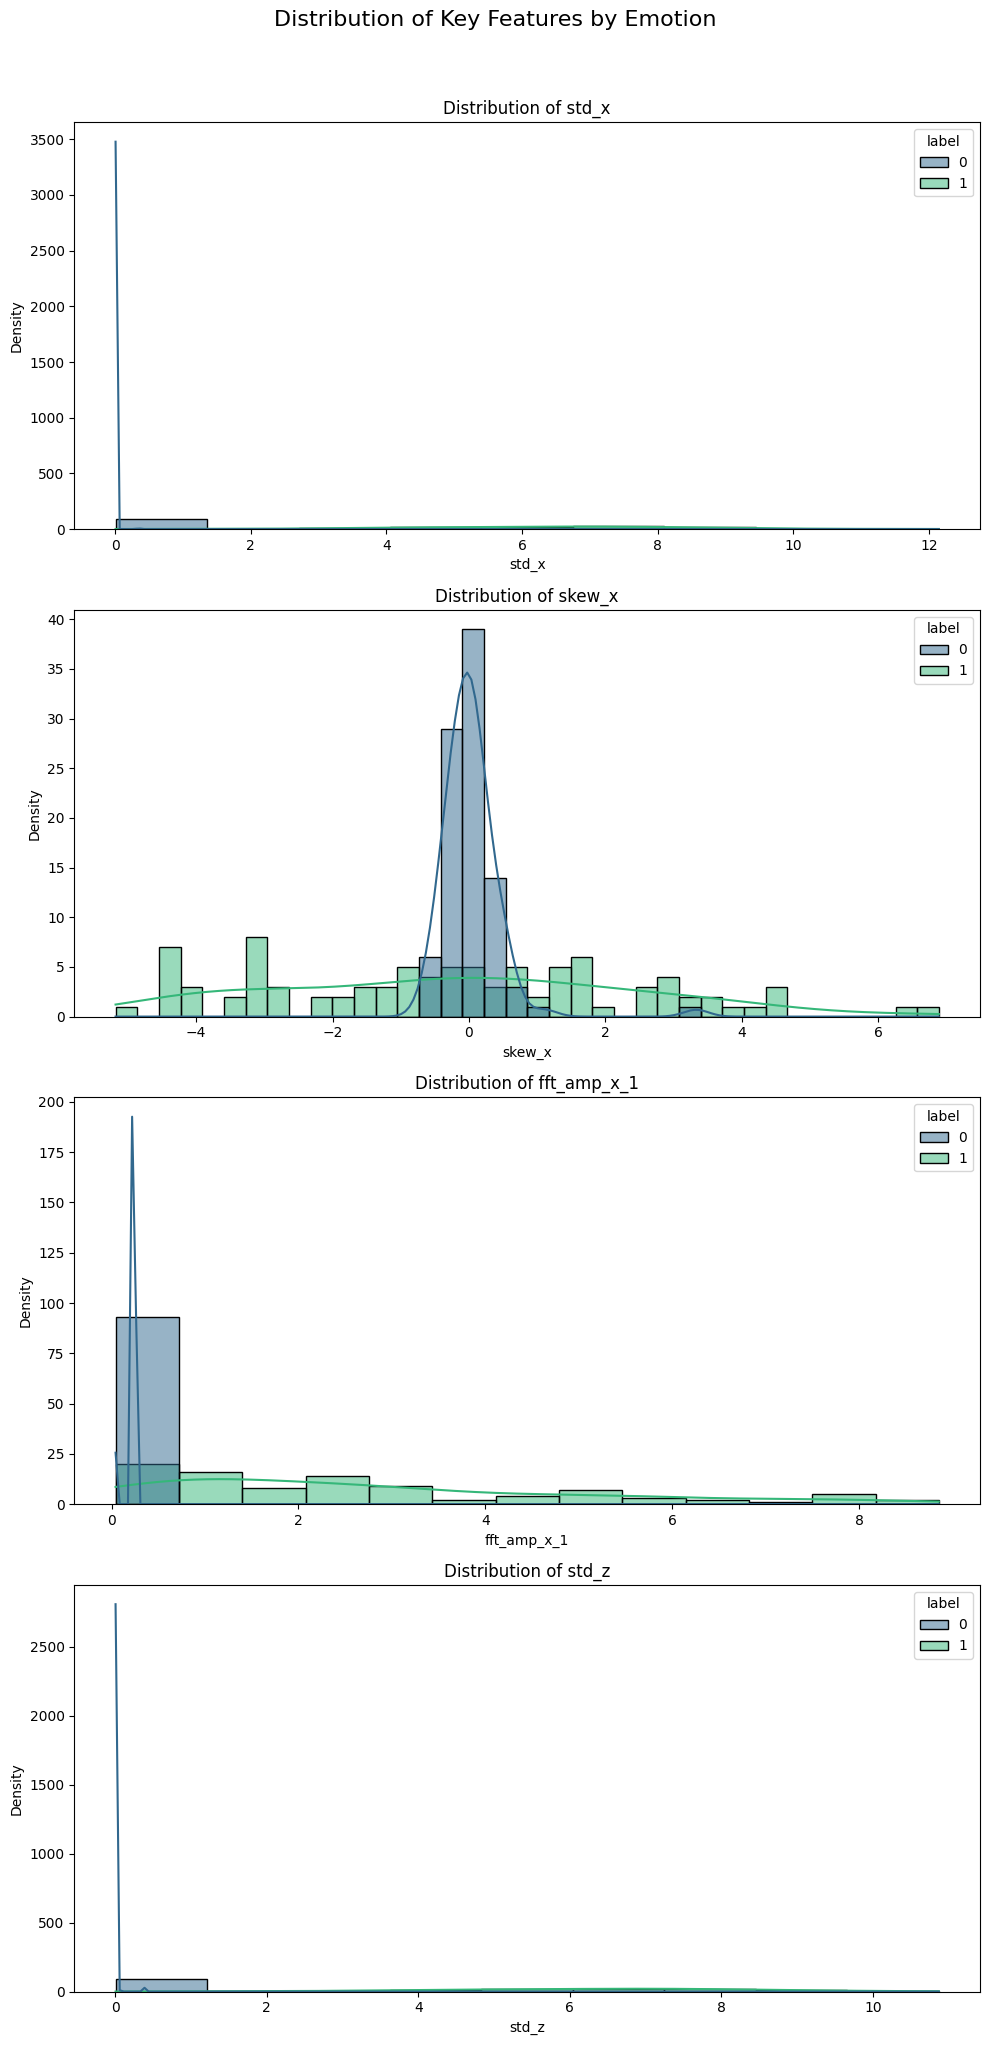


6. Visualizing raw data segment to illustrate 'Calm' vs 'Agitated' characteristics...


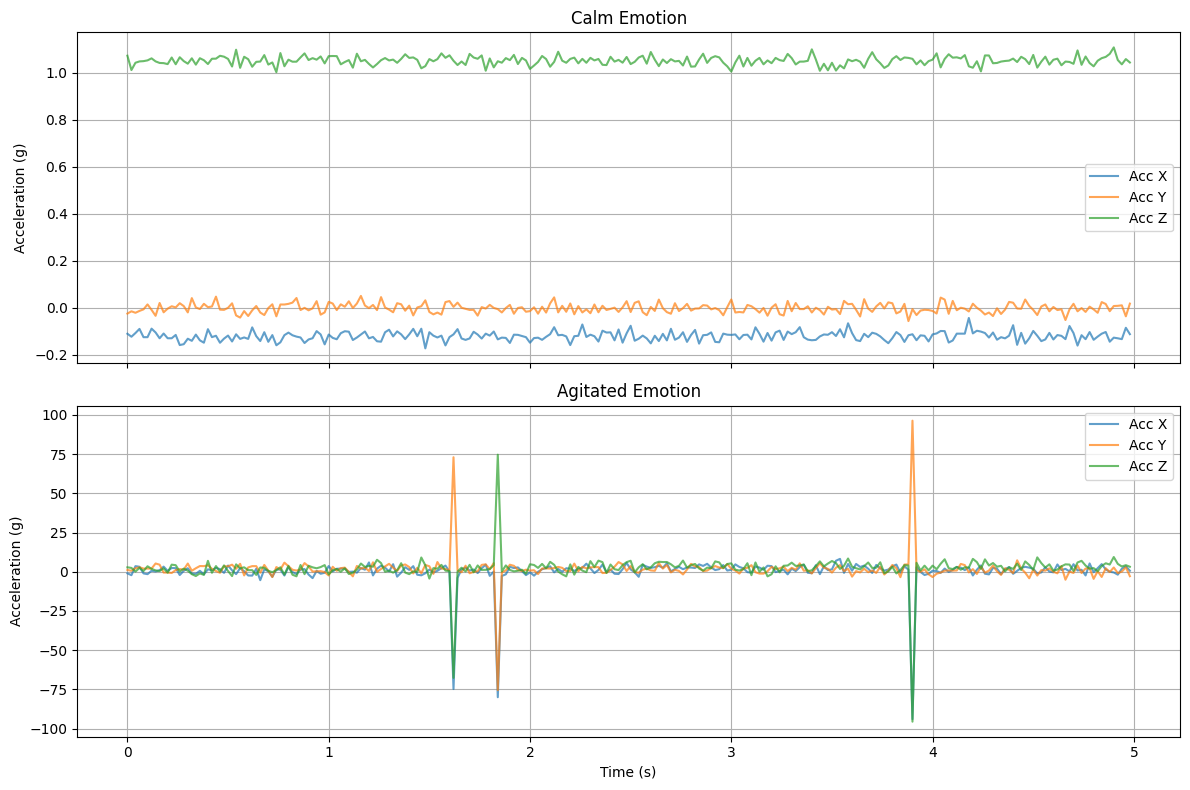

In [7]:
SAMPLING_RATE = 50 # Hz
WINDOW_SIZE = 128 # samples (approx 2.56 seconds at 50 Hz)
OVERLAP = 64 # samples (50% overlap)
MA_WINDOW_SIZE = 5 # Moving Average filter window size

# 1. Generate continuous data for 2 emotions
print("Generating continuous simulated data...")
continuous_data, continuous_labels = generate_simulated_continuous_data(
    duration_per_emotion=120, # 2 minutes per emotion for richer data
    sampling_rate=SAMPLING_RATE
)
print(f"Continuous data shape: {continuous_data.shape}")
print(f"Continuous labels shape: {continuous_labels.shape}")

# Helper function to create a DataFrame for plotting
def create_plot_df(data, labels, sampling_rate, emotion_map):
    df = pd.DataFrame(data, columns=['x_g', 'y_g', 'z_g'])
    df['label'] = labels
    df['state'] = df['label'].map(emotion_map)
    df['batch'] = df.index + 1
    df['time_s'] = df.index / sampling_rate
    return df

# Use the global EMOTION_LABELS for mapping
emotion_map_plot = EMOTION_LABELS

csv_data_df = create_plot_df(continuous_data, continuous_labels, SAMPLING_RATE, emotion_map_plot)

# 2. Apply Moving Average Filter
print(f"\n2. Applying Moving Average Filter with window size {MA_WINDOW_SIZE}...")
filtered_data = moving_average_filter(continuous_data, MA_WINDOW_SIZE)
# Adjust labels to match the length of filtered data
# The moving average filter with mode='valid' reduces the length of the data.
# The new length is N - window_size + 1. So, we slice the labels accordingly.
adjusted_labels = continuous_labels[MA_WINDOW_SIZE - 1:]

print(f"Filtered data shape: {filtered_data.shape}")
print(f"Adjusted labels shape: {adjusted_labels.shape}")

# 3. Apply Sliding Window Segmentation
print(f"\n3. Applying Sliding Window with size {WINDOW_SIZE} and overlap {OVERLAP}...")
windowed_data, windowed_labels = sliding_window(filtered_data, adjusted_labels, WINDOW_SIZE, OVERLAP)
print(f"Number of windows: {len(windowed_data)}")
print(f"Shape of first window: {windowed_data[0].shape}")
print(f"Number of window labels: {len(windowed_labels)}")
print(f"Class distribution in windows: {np.bincount(windowed_labels)}")

# 4. Feature Extraction
print("\n4. Extracting features from windows...")
feature_list = []
for i, window in enumerate(windowed_data):
    feature_list.append(extract_features(window, sampling_rate=SAMPLING_RATE))

# Dynamically create column names for the 114 features
feature_names = []
axes = ['x', 'y', 'z']
for axis in axes:
    feature_names.extend([
        f'std_{axis}', f'skew_{axis}', f'kurt_{axis}',
        f'mean_psd_{axis}', f'std_psd_{axis}',
    ])
    for j in range(32):
        feature_names.append(f'fft_amp_{axis}_{j+1}')
feature_names.extend(['corr_xy', 'corr_xz', 'corr_yz'])

features_df = pd.DataFrame(feature_list, columns=feature_names)
features_df['label'] = windowed_labels

print(f"Shape of features DataFrame: {features_df.shape}")
display(features_df.head())

# 5. Plotting Selected Feature Distributions
print("\n5. Plotting selected feature distributions...")

# Select a few key features for visualization
selected_features = ['std_x', 'skew_x', 'fft_amp_x_1', 'std_z'] # Using first FFT component for demonstration

fig, axes = plt.subplots(len(selected_features), 1, figsize=(10, 5 * len(selected_features)))
fig.suptitle('Distribution of Key Features by Emotion', y=1.02, fontsize=16)

for i, feature in enumerate(selected_features):
    sns.histplot(data=features_df, x=feature, hue='label', kde=True, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


# Visualize raw data for a short segment to see agitation difference
print("\n6. Visualizing raw data segment to illustrate 'Calm' vs 'Agitated' characteristics...")

# Displaying the first few seconds of calm and agitated data
duration_to_plot = 5 # seconds
calm_segment_data = continuous_data[continuous_labels == 0][:duration_to_plot * SAMPLING_RATE]
agitated_segment_data = continuous_data[continuous_labels == 1][:duration_to_plot * SAMPLING_RATE]

time_axis = np.arange(0, duration_to_plot, 1/SAMPLING_RATE)

fig_raw, axes_plot = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot Calm segment
axes_plot[0].plot(time_axis, calm_segment_data[:, 0], label='Acc X', alpha=0.7)
axes_plot[0].plot(time_axis, calm_segment_data[:, 1], label='Acc Y', alpha=0.7)
axes_plot[0].plot(time_axis, calm_segment_data[:, 2], label='Acc Z', alpha=0.7)
axes_plot[0].set_title('Calm Emotion')
axes_plot[0].set_ylabel('Acceleration (g)')
axes_plot[0].legend()
axes_plot[0].grid(True)

# Plot Agitated segment
axes_plot[1].plot(time_axis, agitated_segment_data[:, 0], label='Acc X', alpha=0.7)
axes_plot[1].plot(time_axis, agitated_segment_data[:, 1], label='Acc Y', alpha=0.7)
axes_plot[1].plot(time_axis, agitated_segment_data[:, 2], label='Acc Z', alpha=0.7)
axes_plot[1].set_title('Agitated Emotion')
axes_plot[1].set_xlabel('Time (s)')
axes_plot[1].set_ylabel('Acceleration (g)')
axes_plot[1].legend()
axes_plot[1].grid(True)

plt.tight_layout()
plt.show()

### 4. Refactored End-to-End Pipeline Function

This function encapsulates the entire pipeline: data generation, feature extraction, model training, and evaluation, making it modular and easy to run with different parameters.

In [8]:
def run_accelerometer_pipeline(duration_per_emotion=120, ma_window_size=5, pca_variance_threshold=0.95, test_size=0.3, random_state=42):
    """
    Runs the end-to-end accelerometer data classification pipeline, incorporating changes from the research paper.

    Args:
        duration_per_emotion (int): Duration in seconds for each emotion's continuous data.
        ma_window_size (int): Window size for the Moving Average filter.
        pca_variance_threshold (float): Cumulative explained variance threshold for PCA feature selection.
        test_size (float): Proportion of the dataset to include in the test split.
        random_state (int): Seed for random number generation for reproducibility.

    Returns:
        dict: A dictionary containing evaluation metrics, the trained model, and best parameters.
    """
    print("-- - Starting Accelerometer Classification Pipeline (Paper-Aligned) -- -")

    # Constants (can be made parameters if needed, but fixed as per paper now)
    SAMPLING_RATE = 50 # Hz
    WINDOW_SIZE = 128 # samples (approx 2.56 seconds at 50 Hz)
    OVERLAP = 64 # samples (50% overlap)

    # 1. Data Generation
    print(f"\n1. Generating continuous simulated data for {duration_per_emotion}s per emotion...")
    continuous_data, continuous_labels = generate_simulated_continuous_data(
        duration_per_emotion=duration_per_emotion,
        sampling_rate=SAMPLING_RATE
    )
    print(f"Continuous data shape: {continuous_data.shape}")
    print(f"Continuous labels shape: {continuous_labels.shape}")

    # 2. Preprocessing: Moving Average Filter
    print(f"\n2. Applying Moving Average Filter with window size {ma_window_size}...")
    filtered_data = moving_average_filter(continuous_data, ma_window_size)
    adjusted_labels = continuous_labels[ma_window_size - 1:]
    print(f"Filtered data shape: {filtered_data.shape}")
    print(f"Adjusted labels shape: {adjusted_labels.shape}")

    # 3. Preprocessing: Sliding Window Segmentation
    print(f"\n3. Applying Sliding Window with size {WINDOW_SIZE} and overlap {OVERLAP}...")
    windowed_data, windowed_labels = sliding_window(filtered_data, adjusted_labels, WINDOW_SIZE, OVERLAP)
    print(f"Number of windows: {len(windowed_data)}")
    print(f"Shape of first window: {windowed_data[0].shape}")
    print(f"Number of window labels: {len(windowed_labels)}")
    print(f"Class distribution in windows: {np.bincount(windowed_labels)}")

    # 4. Feature Extraction
    print("\n4. Extracting features from windows...")
    feature_list = []
    for i, window in enumerate(windowed_data):
        feature_list.append(extract_features(window, sampling_rate=SAMPLING_RATE))

    # Dynamically create column names for the 114 features
    feature_names = []
    axes = ['x', 'y', 'z']
    for axis in axes:
        feature_names.extend([
            f'std_{axis}', f'skew_{axis}', f'kurt_{axis}',
            f'mean_psd_{axis}', f'std_psd_{axis}',
        ])
        for j in range(32):
            feature_names.append(f'fft_amp_{axis}_{j+1}')
    feature_names.extend(['corr_xy', 'corr_xz', 'corr_yz'])

    features_df = pd.DataFrame(feature_list, columns=feature_names)
    features_df['label'] = windowed_labels

    print(f"Shape of features DataFrame: {features_df.shape}")
    display(features_df.head())

    # 5. Feature Selection with PCA
    print(f"\n5. Applying PCA for feature selection (explaining > {pca_variance_threshold*100:.0f}% variance)...")
    X = features_df.drop('label', axis=1)
    y = features_df['label']

    pca = PCA(n_components=pca_variance_threshold, svd_solver='full')
    X_pca = pca.fit_transform(X)
    print(f"Original number of features: {X.shape[1]}")
    print(f"Number of features after PCA: {X_pca.shape[1]}")
    print(f"Cumulative explained variance: {pca.explained_variance_ratio_.sum():.4f}")

    # 6. Model Training and Evaluation with Hyperparameter Tuning
    print("\n6. Performing Grid Search for RandomForestClassifier hyperparameter tuning...")

    X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=test_size, random_state=random_state, stratify=y)

    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")

    # Define the parameter grid for RandomForestClassifier (moved here for robustness)
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    }

    # Initialize GridSearchCV
    grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=random_state),
                               param_grid=param_grid,
                               cv=3, # Using 3-fold cross-validation
                               n_jobs=-1, # Use all available cores
                               verbose=1)

    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"\nBest parameters found: {best_params}")

    y_pred = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}")

    print("\nClassification Report:")
    target_names = list(EMOTION_LABELS.values()) # Use global EMOTION_LABELS for target names
    print(classification_report(y_test, y_pred, target_names=target_names))

    print("\nConfusion Matrix:")
    conf_matrix = confusion_matrix(y_test, y_pred)
    display(pd.DataFrame(conf_matrix, index=[f'Actual {name}' for name in target_names], columns=[f'Predicted {name}' for name in target_names]))

    plt.figure(figsize=(7, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names,
                yticklabels=target_names)
    plt.title('Confusion Matrix')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("-- - Pipeline Finished -- -")
    return {
        "model": best_model,
        "accuracy": accuracy,
        "classification_report": classification_report(y_test, y_pred, target_names=target_names, output_dict=True),
        "confusion_matrix": conf_matrix,
        "pca_components": pca.n_components_,
        "best_params": best_params
    }

### 5. Execute the Pipeline

Run the entire classification pipeline with a single function call, using parameters that create a challenging classification task.

-- - Starting Accelerometer Classification Pipeline (Paper-Aligned) -- -

1. Generating continuous simulated data for 120s per emotion...
Continuous data shape: (12000, 3)
Continuous labels shape: (12000,)

2. Applying Moving Average Filter with window size 5...
Filtered data shape: (11996, 3)
Adjusted labels shape: (11996,)

3. Applying Sliding Window with size 128 and overlap 64...
Number of windows: 186
Shape of first window: (128, 3)
Number of window labels: 186
Class distribution in windows: [93 93]

4. Extracting features from windows...
Shape of features DataFrame: (186, 115)


,std_x,skew_x,kurt_x,mean_psd_x,std_psd_x,fft_amp_x_1,fft_amp_x_2,fft_amp_x_3,fft_amp_x_4,fft_amp_x_5,...,fft_amp_z_27,fft_amp_z_28,fft_amp_z_29,fft_amp_z_30,fft_amp_z_31,fft_amp_z_32,corr_xy,corr_xz,corr_yz,label
0,0.011432,0.021854,-0.419391,0.000005,0.000011,0.241040,0.010590,0.002688,0.002181,0.002932,...,0.000022,0.000140,0.000436,0.000286,0.000380,0.000202,-0.240371,0.170320,0.243774,0
1,0.009129,-0.746348,0.134418,0.000002,0.000006,0.240250,0.008108,0.002003,0.001399,0.001545,...,0.000049,0.000037,0.000336,0.000619,0.000156,0.000588,-0.144963,0.065692,0.071266,0
2,0.007118,-0.298174,0.042879,0.000002,0.000004,0.233978,0.003611,0.002605,0.002745,0.002362,...,0.000123,0.000180,0.000225,0.000310,0.000899,0.000941,-0.071515,0.213781,0.020225,0
3,0.009949,-0.073792,-0.252615,0.000005,0.000010,0.239902,0.002726,0.007766,0.000700,0.003987,...,0.000208,0.000242,0.000361,0.001055,0.000646,0.001624,-0.081415,0.136900,0.030517,0
4,0.009122,0.022240,0.247882,0.000002,0.000007,0.241532,0.003124,0.004623,0.004483,0.001242,...,0.000194,0.000203,0.000302,0.000829,0.000688,0.001157,-0.152065,0.033657,-0.084292,0



5. Applying PCA for feature selection (explaining > 95% variance)...
Original number of features: 114
Number of features after PCA: 9
Cumulative explained variance: 0.9540

6. Performing Grid Search for RandomForestClassifier hyperparameter tuning...
X_train shape: (130, 9)
y_train shape: (130,)
X_test shape: (56, 9)
y_test shape: (56,)
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        Calm       1.00      1.00      1.00        28
    Agitated       1.00      1.00      1.00        28

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56


Confusion Matrix:


,Predicted Calm,Predicted Agitated
Actual Calm,28,0
Actual Agitated,0,28


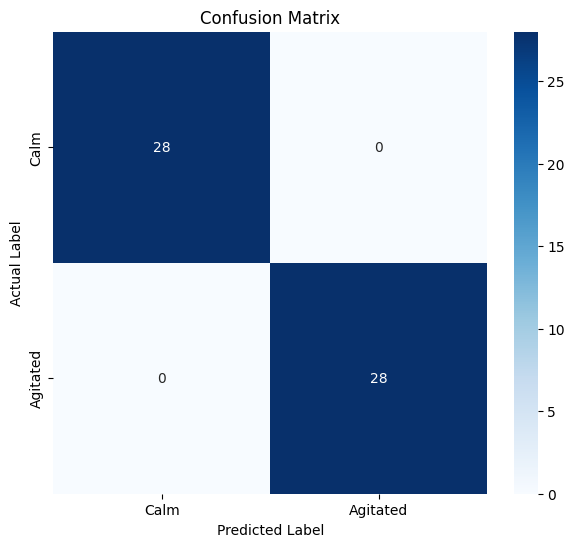

-- - Pipeline Finished -- -
Final Accuracy: 1.0000
Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
RandomForestClassifier(random_state=43)


In [9]:
pipeline_results = run_accelerometer_pipeline(
    duration_per_emotion=120, # Duration for each emotion class
    ma_window_size=5, # Moving average window size
    pca_variance_threshold=0.95, # PCA variance threshold
    test_size=0.3,
    random_state=43 # Changed random_state to force re-execution
)

# You can access results like this:
print(f"Final Accuracy: {pipeline_results['accuracy']:.4f}")
print(f"Best Parameters: {pipeline_results['best_params']}")
print(pipeline_results['model'])

### Plotting Predicted Probabilities vs. Actual Labels

To visualize the model's confidence, we will plot the distribution of predicted probabilities (for the 'Agitated' class) separately for actual 'Calm' and 'Agitated' samples from the test set.

In [10]:
# Re-run data generation and feature extraction to get X_pca and y for plotting
SAMPLING_RATE = 50 # Hz
WINDOW_SIZE = 128 # samples
OVERLAP = 64 # samples
MA_WINDOW_SIZE = 5 # Moving Average filter window size
DURATION_PER_EMOTION = 120 # From previous pipeline run
PCA_VARIANCE_THRESHOLD = 0.95 # From previous pipeline run
TEST_SIZE = 0.3 # From previous pipeline run
RANDOM_STATE = 43 # From previous pipeline run

# 1. Generate continuous data
continuous_data_plot, continuous_labels_plot = generate_simulated_continuous_data(
    duration_per_emotion=DURATION_PER_EMOTION,
    sampling_rate=SAMPLING_RATE
)

# 2. Apply Moving Average Filter
filtered_data_plot = moving_average_filter(continuous_data_plot, MA_WINDOW_SIZE)
adjusted_labels_plot = continuous_labels_plot[MA_WINDOW_SIZE - 1:]

# 3. Apply Sliding Window Segmentation
windowed_data_plot, windowed_labels_plot = sliding_window(filtered_data_plot, adjusted_labels_plot, WINDOW_SIZE, OVERLAP)

# 4. Feature Extraction
feature_list_plot = []
for window in windowed_data_plot:
    feature_list_plot.append(extract_features(window, sampling_rate=SAMPLING_RATE))

# Dynamically create column names (reusing logic from pipeline)
feature_names_plot = []
axes = ['x', 'y', 'z']
for axis in axes:
    feature_names_plot.extend([
        f'std_{axis}', f'skew_{axis}', f'kurt_{axis}',
        f'mean_psd_{axis}', f'std_psd_{axis}',
    ])
    for j in range(32):
        feature_names_plot.append(f'fft_amp_{axis}_{j+1}')
feature_names_plot.extend(['corr_xy', 'corr_xz', 'corr_yz'])

features_df_plot = pd.DataFrame(feature_list_plot, columns=feature_names_plot)

X_full_plot = features_df_plot # Features before PCA
y_full_plot = windowed_labels_plot # Corresponding labels

# 5. Apply PCA (using the same n_components as in the trained model for consistency)
# We fit a new PCA transformer with the same parameters as the one saved.
# However, to be consistent with the pipeline, we need to apply PCA on the *full* dataset (X_full_plot)
# and then perform train-test split *after* PCA, as done in the run_accelerometer_pipeline.

pca_n_components_trained = pipeline_results['pca_components']
pca_plot = PCA(n_components=pca_n_components_trained, svd_solver='full')
X_pca_plot = pca_plot.fit_transform(X_full_plot)

# 6. Train-test split (using the same random_state as in the pipeline)
X_train_plot, X_test_plot, y_train_plot, y_test_plot = train_test_split(
    X_pca_plot, y_full_plot, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_full_plot
)

print("Data and features for plotting prepared.")

Data and features for plotting prepared.


/tmp/ipykernel_3780/3142080549.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Actual Emotion')


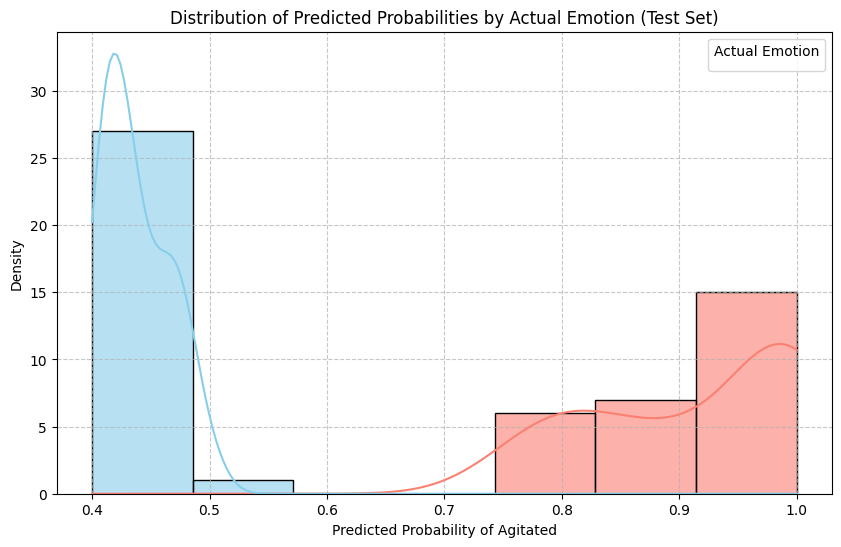

/tmp/ipykernel_3780/3142080549.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


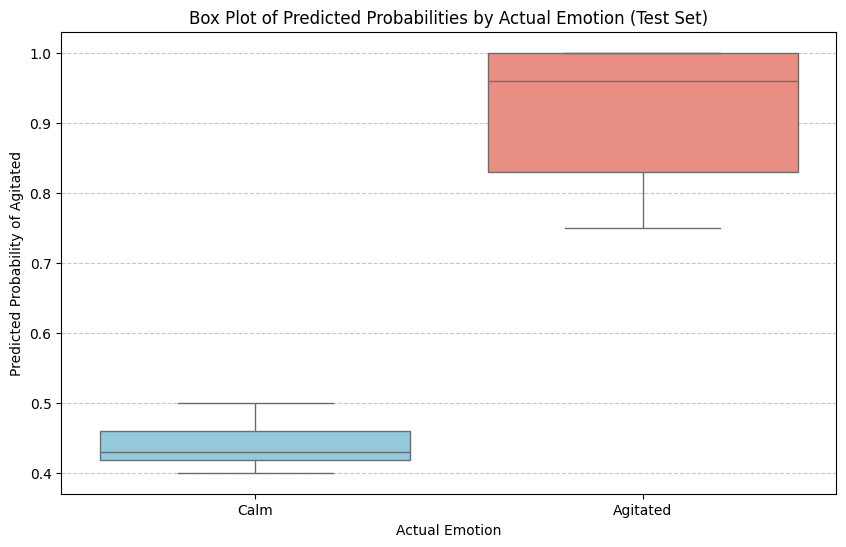

In [11]:
# Get the trained model from the pipeline results
model = pipeline_results['model']

# Predict probabilities on the X_test_plot
# We are interested in the probability of the 'Agitated' class (label 1)
predicted_proba_agitated = model.predict_proba(X_test_plot)[:, 1]

# Create a DataFrame for plotting
plot_df = pd.DataFrame({
    'Actual Label': y_test_plot,
    'Predicted Probability (Agitated)': predicted_proba_agitated
})

# Map numerical labels to emotion names for better readability in the plot
plot_df['Actual Emotion'] = plot_df['Actual Label'].map(EMOTION_LABELS)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=plot_df,
    x='Predicted Probability (Agitated)',
    hue='Actual Emotion',
    kde=True,
    palette={'Calm': 'skyblue', 'Agitated': 'salmon'},
    alpha=0.6,
    common_norm=False # Normalize histograms independently
)
plt.title('Distribution of Predicted Probabilities by Actual Emotion (Test Set)')
plt.xlabel('Predicted Probability of Agitated')
plt.ylabel('Density')
plt.legend(title='Actual Emotion')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=plot_df,
    x='Actual Emotion',
    y='Predicted Probability (Agitated)',
    palette={'Calm': 'skyblue', 'Agitated': 'salmon'}
)
plt.title('Box Plot of Predicted Probabilities by Actual Emotion (Test Set)')
plt.xlabel('Actual Emotion')
plt.ylabel('Predicted Probability of Agitated')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [12]:
import joblib
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

# --- 1. Save Model Checkpoint and PCA Transformer ---

print("\nSaving trained model and PCA transformer...")

# Retrieve the trained model from pipeline_results
model_to_save = pipeline_results['model']

# Re-fit PCA using the same parameters as in the pipeline execution
# This ensures the PCA transformation applied during inference is consistent with training.
# We use the 'features_df' which holds the extracted features before train-test split.
# Ensure to drop both 'label' and any other non-numeric columns like 'emotion'
X_full = features_df.drop(['label'], axis=1)

# CRITICAL FIX: Use the exact number of PCA components determined during training
# This ensures consistency between the trained model and the PCA transformer used for inference.
pca_n_components_trained = pipeline_results['pca_components']
fitted_pca = PCA(n_components=pca_n_components_trained, svd_solver='full')
fitted_pca.fit(X_full)

# Define file paths
model_filename = 'random_forest_model.joblib'
pca_filename = 'pca_transformer.joblib'

# Save the model and PCA transformer
joblib.dump(model_to_save, model_filename)
joblib.dump(fitted_pca, pca_filename)

print(f"Model saved to: {model_filename}")
print(f"PCA transformer saved to: {pca_filename}")

# --- 2. Real-time Inference Function ---

print("\nDefining real-time inference function...")

def predict_realtime(raw_data_window_list, model, pca_transformer, sampling_rate, ma_window_size, window_size_trained, feature_names_list):
    """
    Performs real-time prediction on a single window of raw accelerometer data.
    Adheres to the specified ML Data Struct Contract for input and output.

    Args:
        raw_data_window_list (list): A list of dictionaries, each representing a single sample.
                                     e.g., [{'ax': ..., 'ay': ..., 'az': ..., 't': ...}, ...]
        model: The trained classification model (e.g., RandomForestClassifier).
        pca_transformer: The fitted PCA transformer.
        sampling_rate (int): The sampling rate used during feature extraction.
        ma_window_size (int): Window size for the Moving Average filter.
        window_size_trained (int): The WINDOW_SIZE used during model training.
        feature_names_list (list): A list of feature names used during training.

    Returns:
        dict: A dictionary with the predicted 'stress' probability.
              e.g., {'stress': 0.42}
    """
    # 1. Convert list of dicts to NumPy array (WINDOW_SIZE, 3)
    if not isinstance(raw_data_window_list, list):
        raise TypeError("Input raw_data_window_list must be a list of dictionaries.")

    if len(raw_data_window_list) != window_size_trained:
        raise ValueError(f"Input window length ({len(raw_data_window_list)}) must match the trained window size ({window_size_trained}).")

    # Extract ax, ay, az values and form a NumPy array
    raw_data_window = np.array([
        [sample['ax'], sample['ay'], sample['az']] for sample in raw_data_window_list
    ])

    # Ensure the input window is 2D (time_steps, axes)
    if raw_data_window.ndim != 2 or raw_data_window.shape[1] != 3:
        raise ValueError("raw_data_window must be a 2D array with shape (time_steps, 3).")

    # 2. Apply Moving Average Filter
    filtered_window = moving_average_filter(raw_data_window, ma_window_size)

    # 3. Extract Features
    features_array = extract_features(filtered_window, sampling_rate)

    # Reshape for PCA (PCA expects 2D array: n_samples, n_features)
    features_array_reshaped = features_array.reshape(1, -1)

    # CRITICAL FIX: Convert to DataFrame with correct feature names for PCA consistency
    features_df_for_pca = pd.DataFrame(features_array_reshaped, columns=feature_names_list)

    # 4. Apply PCA transformation
    pca_features = pca_transformer.transform(features_df_for_pca)

    # 5. Predict probability using the model
    # For binary classification (0: Calm, 1: Agitated), predict_proba returns probabilities
    # for each class. We want the probability of the 'Agitated' class (index 1).
    predicted_proba = model.predict_proba(pca_features)[0][1] # Probability of class 1 (Agitated)

    return {"stress": predicted_proba}

print("Real-time inference function 'predict_realtime' defined (contract-aligned).")

# --- 3. Demonstrate Real-time Inference ---

print("\nDemonstrating real-time inference (contract-aligned)...")

# Load the saved model and PCA transformer
loaded_model = joblib.load(model_filename)
loaded_pca = joblib.load(pca_filename)

# Get parameters used during training from the previous pipeline run
sampling_rate_used = SAMPLING_RATE # From kernel state
ma_window_size_used = MA_WINDOW_SIZE # From kernel state
window_size_trained = WINDOW_SIZE # From kernel state

# Ensure feature_names is available globally or passed correctly
# This feature_names list was generated in section 5. Demonstration of Data Generation, Preprocessing, and Feature Distribution Plotting
# and is used for X_full construction.

# Take an example window from the generated data (e.g., the first window)
# Convert the example_raw_window (NumPy array) back to the expected list of dicts format
example_raw_window_np = windowed_data[0]
example_raw_window_list = [
    {'ax': x, 'ay': y, 'az': z, 't': i * (1000 // sampling_rate_used)} # Simulate 't' in ms
    for i, (x, y, z) in enumerate(example_raw_window_np)
]

print(f"Example raw window list length: {len(example_raw_window_list)}")
print(f"First sample in example list: {example_raw_window_list[0]}")

# Perform real-time prediction
prediction_output = predict_realtime(
    example_raw_window_list,
    loaded_model,
    loaded_pca,
    sampling_rate_used,
    ma_window_size_used,
    window_size_trained,
    feature_names # Pass the global feature_names list
)

# Map label back to emotion name for comparison with true label - using global EMOTION_LABELS
# emotion_map_inference = {0: 'Neutral', 1: 'Agitated'}

print(f"Prediction Output: {prediction_output}")

# Determine the predicted class based on a threshold (e.g., 0.5)
predicted_label_from_proba = 1 if prediction_output['stress'] >= 0.5 else 0
predicted_emotion = EMOTION_LABELS[predicted_label_from_proba] # Use global EMOTION_LABELS

print(f"Inferred emotion (threshold 0.5): {predicted_emotion}")

# Compare with the true label for this window
true_label = windowed_labels[0]
true_emotion = EMOTION_LABELS[true_label] # Use global EMOTION_LABELS
print(f"True label for the example window: {true_label} ({true_emotion})")


Saving trained model and PCA transformer...
Model saved to: random_forest_model.joblib
PCA transformer saved to: pca_transformer.joblib

Defining real-time inference function...
Real-time inference function 'predict_realtime' defined (contract-aligned).

Demonstrating real-time inference (contract-aligned)...
Example raw window list length: 128
First sample in example list: {'ax': np.float64(-0.11081994051349829), 'ay': np.float64(-0.015796874019989797), 'az': np.float64(1.045769146767891), 't': 0}
Prediction Output: {'stress': np.float64(0.4)}
Inferred emotion (threshold 0.5): Calm
True label for the example window: 0 (Calm)
